# STARIT Tutorial: Choosing the Pixel Size (`dx`) and Blur (`blur`) Parameters

This tutorial explains the two STARIT parameters that control how imSRT transcript *x,y* coordinates become an image: the pixel size `dx` and the Gaussian blur `blur`. We show what each parameter does inside `starit()`, how the two interact, and how the choice affects downstream analysis on the simulated nuclear–perinuclear datasets with and without sparse-gene count noise. The end of the notebook has a checklist for picking values for your own imSRT data. More information on STARIT and these datasets can be found in the [paper](https://doi.org/10.64898/2025.12.18.695193).

This tutorial assumes you have worked through [Running STARIT on Simulated Dataset](simulated_data_example.ipynb) and [Running STARIT on Simulated Dataset with Noise](simulated_data_noise_example.ipynb). It reuses their data and their ResNet-101 → PCA → Louvain pipeline.

### Learning Objectives

By the end of the notebook, you will be able to:

1. explain what `dx` and `blur` control and how they combine into one physical smoothing scale
2. predict the size of the raster grid and the cost of rasterization for a given `dx`
3. recognize when blur is too small (isolated dots) or too large (compartments merge)
4. understand how sparse genes and per-image min–max normalization interact with blur
5. measure how `dx` and `blur` affect clustering of the simulated groups and
6. choose starting values of `dx` and `blur` for your own imSRT data

### Input Files

- `data/simulated_nuclear_peri/simulation_nuclear_peri_dataset.csv`: noise-free simulation, one transcript per row, with `x_position`, `y_position`, `gene_id`, `cell_id`, and `group_id`.
- `data/simulation_nuclear_peri_dataset_with_noise.csv`: the same design with 1–3 sparse "noise" transcripts added for non-marker genes.

Run the notebook from the repository root so these relative paths resolve correctly. Unlike the other tutorials, this notebook does **not** write STARIT images to disk. Every raster is created in memory, so running it will not overwrite the image folders that the other tutorials use.

## 1. Reproducible Environment and Installation

This notebook uses the same environment as the other STARIT tutorials. See **Section 1** of [Running STARIT on Simulated Dataset](simulated_data_example.ipynb) for the full software and version table and the Conda setup. Sections 2–6 need only STARIT, NumPy, Matplotlib, and pandas. Section 7 (downstream clustering) also needs Pillow, scikit-learn, NetworkX, python-louvain, PyTorch, and TorchVision.

If you are running this notebook in **Google Colab** or a standalone **Jupyter Notebook**, uncomment and execute the cell below to clone the repository, install the pinned package versions, and set up STARIT in editable mode.

> **Note for Google Colab Users:** Once the dependencies install, you may need to restart the runtime (**Runtime > Restart session**) for updated package versions to take effect.

In [1]:
# 1. Clone the repository (skip if running locally from within the cloned repository)
#!git clone https://github.com/JEFworks-Lab/STARIT.git
#%cd STARIT

# 2. Install required dependencies with exact pinned versions
#!python -m pip install \
#  numpy==1.26.4 \
#  matplotlib==3.8.0 \
#  pandas==2.1.4 \
#  pillow==10.2.0 \
#  scikit-learn==1.2.2 \
#  networkx==3.1 \
#  python-louvain==0.16 \
#  torch==2.7.1 \
#  torchvision==0.22.1

# 3. Install the local STARIT package
#!python -m pip install -e .

## 2. Import Packages and Load the Simulation Datasets

We import the required packages, fix the NumPy and PyTorch random seeds, and load both simulated datasets. As in the other tutorials, one bounding box is computed per dataset from all transcript coordinates, so every cell–gene image shares the same coordinate frame.

In [2]:
# Standard-library utilities
import contextlib
import io
import time

# Data handling and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# STARIT rasterization
from starit import get_bounding_box, save_image, starit

# Feature extraction, clustering, and evaluation (Section 7)
import community.community_louvain as cl
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import kneighbors_graph
import torch
from torchvision import models, transforms

# Fix stochastic components so repeated runs are comparable.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Colors for the two localization groups that only differ in gene2 placement.
GROUP_COLORS = {"group2": "#2a78d6", "group3": "#eb6834"}
DATASET_COLORS = {"noise-free": "#2a78d6", "with noise": "#eb6834"}

# Load the noise-free and noisy simulations.
dataset = pd.read_csv("data/simulated_nuclear_peri/simulation_nuclear_peri_dataset.csv")
dataset_noise = pd.read_csv("data/simulation_nuclear_peri_dataset_with_noise.csv")

bounding_box = get_bounding_box(dataset["x_position"], dataset["y_position"])
bounding_box_noise = get_bounding_box(dataset_noise["x_position"], dataset_noise["y_position"])

print("Noise-free dataset:", dataset.shape, "| bounding box:", np.round(bounding_box, 1))
print("Noisy dataset:     ", dataset_noise.shape, "| bounding box:", np.round(bounding_box_noise, 1))

Noise-free dataset: (4000, 5) | bounding box: [ 30.6 193.4  31.6 194.4]
Noisy dataset:      (4256, 5) | bounding box: [ 29.6 192.4  29.6 193.4]


### Inspect the Simulated Groups

Each group has 20 cells with 50 transcripts of one marker gene. Groups 2 and 3 express the **same** gene (`gene2`) at the **same** count and differ only in where the transcripts sit: group 2 is nuclear (a disk near the cell center) and group 3 is perinuclear (a ring around the nucleus). Gene counts cannot distinguish these two groups. Only spatial information can, so these two groups are the ones most sensitive to `dx` and `blur`.

The radial distance of each transcript from the center of the bounding box shows how close together the two compartments are.

In [3]:
# Summarize transcript counts and radial position per group.
center_x = (bounding_box[0] + bounding_box[1]) / 2
center_y = (bounding_box[2] + bounding_box[3]) / 2
dataset["radius"] = np.hypot(dataset["x_position"] - center_x, dataset["y_position"] - center_y)

summary = dataset.groupby(["group_id", "gene_id"]).agg(
    transcripts_per_cell=("cell_id", lambda s: s.value_counts().mean()),
    median_radius=("radius", "median"),
    min_radius=("radius", "min"),
    max_radius=("radius", "max"),
)
print(summary.round(1))

                  transcripts_per_cell  median_radius  min_radius  max_radius
group_id gene_id                                                             
group1   gene1                    50.0           52.7         1.4        75.7
group2   gene2                    50.0           20.2         1.4        36.1
group3   gene2                    50.0           35.0        23.5        46.9
group4   gene3                    50.0           52.4         2.0        75.8


The nuclear transcripts in group 2 extend to a radius of about 35 coordinate units and the perinuclear ring in group 3 starts at about 25. The gap between the two compartments is therefore only around 10–15 units. Keep this length scale in mind: **any smoothing much larger than this gap will start to blur the nucleus and the ring into similar shapes.**

## 3. How `dx` and `blur` Work Inside `starit()`

`starit()` builds the image in three steps:

1. **Grid (`dx`).** It lays a pixel grid over the bounding box with spacing `dx`, in the **same units as your *x,y* coordinates**. The grid has about `(max_x - min_x) / dx` columns and `(max_y - min_y) / dx` rows.
2. **Kernel (`blur`, `dx`).** Each transcript is replaced by a small Gaussian "splat" centered on its exact (sub-pixel) position. In the code, the Gaussian standard deviation is

   $$\sigma_{\text{physical}} = 2 \cdot \texttt{blur} \cdot \texttt{dx} \quad\text{(coordinate units)}, \qquad \sigma_{\text{pixels}} = 2 \cdot \texttt{blur}.$$

   With `use_windowing=True` (the default), each splat is evaluated in a square window of ±`ceil(4·blur)` pixels (≈ ±2σ) around the transcript. It is then normalized to sum to 1, so every transcript adds the same total intensity.
3. **Display.** The splats are summed. The figure that `starit()` returns (and that `save_image()` writes) shows this sum **min–max normalized per image**, so the brightest pixel of every image is 1.

The most important consequence is in step 2: **`blur` is measured in pixels, so the physical smoothing depends on `dx` too.** If you halve `dx` and keep `blur` fixed, you get a finer grid **and** half as much physical smoothing. To change the resolution without changing the smoothing, keep `blur × dx` constant.

The helper below calls `starit()` and returns the rasterized array (taken from the returned figure) together with its pixel coordinates. `draw` must be non-zero for `starit()` to return a figure, and the progress messages it prints are suppressed.

In [4]:
def rasterize(bbox, x, y, dx, blur):
    """Run STARIT and return pixel coordinates and the min-max normalized raster array."""
    with contextlib.redirect_stdout(io.StringIO()):
        X, Y, fig = starit(bbox, np.asarray(x), np.asarray(y), dx=dx, blur=blur, draw=10000)
    raster = fig.axes[0].images[0].get_array()[..., 0].copy()  # single blur -> grayscale
    plt.close(fig)
    return X, Y, raster


def render_png(bbox, x, y, dx, blur):
    """Run STARIT and return the image exactly as save_image() would write it."""
    with contextlib.redirect_stdout(io.StringIO()):
        _, _, fig = starit(bbox, np.asarray(x), np.asarray(y), dx=dx, blur=blur, draw=10000)
    buffer = io.BytesIO()
    save_image(fig, buffer)
    plt.close(fig)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


def show_raster(ax, X, Y, raster, title):
    """Plot a raster in physical coordinates so different dx values are comparable."""
    half = (X[1] - X[0]) / 2 if len(X) > 1 else 0.5
    ax.imshow(raster, cmap="gray", origin="lower", vmin=0, vmax=1,
              extent=(X[0] - half, X[-1] + half, Y[0] - half, Y[-1] + half), interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

### A Single Transcript

To see the kernel by itself, we rasterize **one** transcript in a small 40 × 40 unit frame.

- **Top row:** `blur = 1` and increasing `dx`. Pixels get coarser **and** the spot gets physically wider, because σ = 2·`blur`·`dx` grows with `dx`.
- **Bottom row:** `blur` adjusted so that `blur × dx = 4` (σ = 8 units). The physical size of the spot stays the same and only the pixelation changes.

The axes are in coordinate units in every panel, so the panels can be compared directly. Each spot also has a faint square edge: the kernel is only evaluated in a window of ±`ceil(4·blur)` pixels (±2σ), so the Gaussian is cut off at that square boundary.

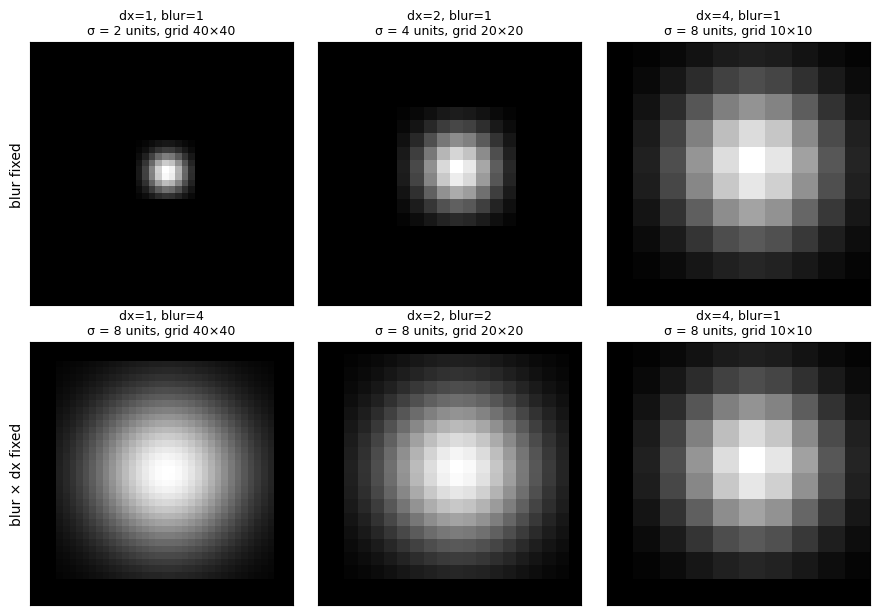

In [5]:
# One transcript in the middle of a 40 x 40 frame.
toy_bbox = (0.0, 40.0, 0.0, 40.0)
toy_x, toy_y = np.array([20.3]), np.array([19.6])

fixed_blur = [(1, 1), (2, 1), (4, 1)]
fixed_sigma = [(1, 4), (2, 2), (4, 1)]

fig, axes = plt.subplots(2, 3, figsize=(9, 6.2))
for ax, (dx, blur) in zip(axes[0], fixed_blur):
    X, Y, r = rasterize(toy_bbox, toy_x, toy_y, dx, blur)
    show_raster(ax, X, Y, r, f"dx={dx}, blur={blur}\nσ = {2*blur*dx:g} units, grid {r.shape[1]}×{r.shape[0]}")
for ax, (dx, blur) in zip(axes[1], fixed_sigma):
    X, Y, r = rasterize(toy_bbox, toy_x, toy_y, dx, blur)
    show_raster(ax, X, Y, r, f"dx={dx}, blur={blur}\nσ = {2*blur*dx:g} units, grid {r.shape[1]}×{r.shape[0]}")
axes[0, 0].set_ylabel("blur fixed", fontsize=10)
axes[1, 0].set_ylabel("blur × dx fixed", fontsize=10)
plt.tight_layout()
plt.show()

The table below summarizes the quantities that follow from `dx` and `blur` for the simulated dataset's bounding box. The window is the square region each transcript writes into. Its size depends only on `blur`, so the cost **per transcript** is set by `blur`, while the size of the image array is set by `dx`.

In [6]:
rows = []
width = bounding_box[1] - bounding_box[0]
height = bounding_box[3] - bounding_box[2]
for dx, blur in [(0.5, 1), (1, 0.25), (1, 1), (1, 4), (2, 1), (4, 1), (8, 1), (1, 8)]:
    window = 2 * int(np.ceil(4 * blur)) + 1
    rows.append({
        "dx": dx,
        "blur": blur,
        "sigma (pixels)": 2 * blur,
        "sigma (coord. units)": 2 * blur * dx,
        "grid (cols x rows)": f"{int(np.ceil(width / dx))} x {int(np.ceil(height / dx))}",
        "window per transcript (pixels)": f"{window} x {window}",
    })
pd.DataFrame(rows)

,dx,blur,sigma (pixels),sigma (coord. units),grid (cols x rows),window per transcript (pixels)
0,0.5,1.00,2.0,1.0,326 x 326,9 x 9
1,1.0,0.25,0.5,0.5,163 x 163,3 x 3
2,1.0,1.00,2.0,2.0,163 x 163,9 x 9
3,1.0,4.00,8.0,8.0,163 x 163,33 x 33
4,2.0,1.00,2.0,4.0,82 x 82,9 x 9
5,4.0,1.00,2.0,8.0,41 x 41,9 x 9
6,8.0,1.00,2.0,16.0,21 x 21,9 x 9
7,1.0,8.00,16.0,16.0,163 x 163,65 x 65


## 4. Effect on Real Simulated Cells

We now rasterize one nuclear cell (group 2) and one perinuclear cell (group 3), varying one parameter at a time. Each cell has 50 `gene2` transcripts.

In [7]:
def cell_xy(data, cell_id, gene_id):
    subset = data[(data["cell_id"] == cell_id) & (data["gene_id"] == gene_id)]
    return subset["x_position"].values, subset["y_position"].values

example_cells = {
    "group2": dataset.loc[dataset["group_id"] == "group2", "cell_id"].iloc[0],
    "group3": dataset.loc[dataset["group_id"] == "group3", "cell_id"].iloc[0],
}
print("Example cells:", example_cells)

Example cells: {'group2': 21, 'group3': 41}


### Varying `blur` at `dx = 1`

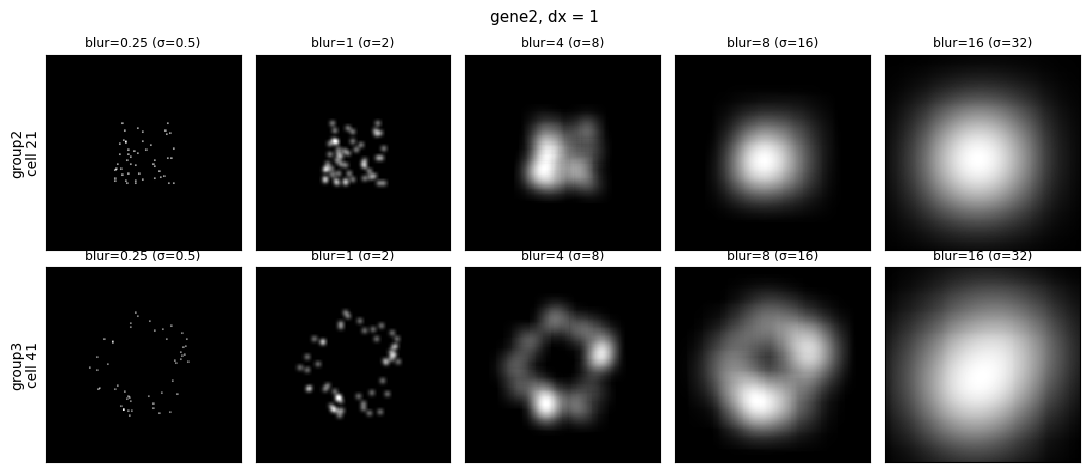

In [8]:
blur_values = [0.25, 1, 4, 8, 16]

fig, axes = plt.subplots(2, len(blur_values), figsize=(2.2 * len(blur_values), 4.8))
for row, (group_id, cell_id) in enumerate(example_cells.items()):
    x, y = cell_xy(dataset, cell_id, "gene2")
    for col, blur in enumerate(blur_values):
        X, Y, r = rasterize(bounding_box, x, y, dx=1, blur=blur)
        show_raster(axes[row, col], X, Y, r, f"blur={blur} (σ={2*blur:g})")
    axes[row, 0].set_ylabel(f"{group_id}\ncell {cell_id}", fontsize=10)
fig.suptitle("gene2, dx = 1", fontsize=11)
plt.tight_layout()
plt.show()

### Varying `dx` at `blur = 1`

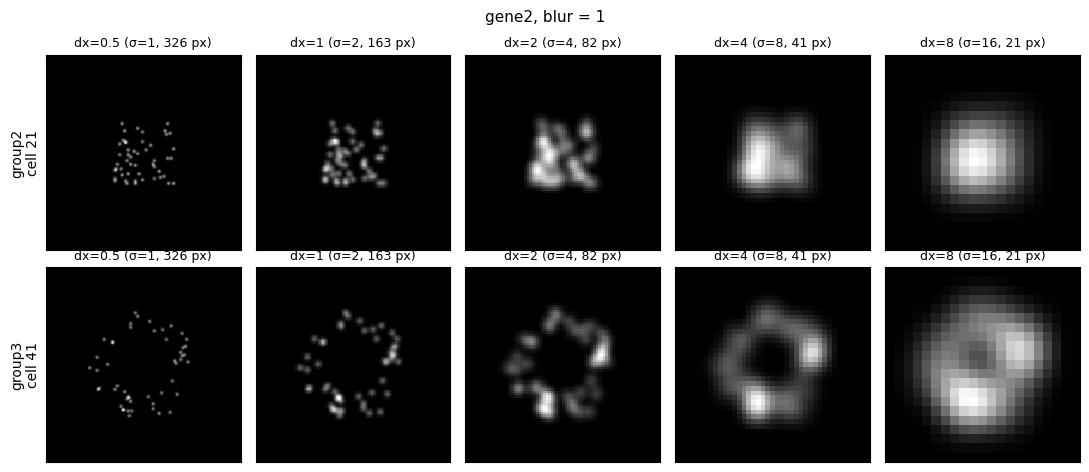

In [9]:
dx_values = [0.5, 1, 2, 4, 8]

fig, axes = plt.subplots(2, len(dx_values), figsize=(2.2 * len(dx_values), 4.8))
for row, (group_id, cell_id) in enumerate(example_cells.items()):
    x, y = cell_xy(dataset, cell_id, "gene2")
    for col, dx in enumerate(dx_values):
        X, Y, r = rasterize(bounding_box, x, y, dx=dx, blur=1)
        show_raster(axes[row, col], X, Y, r, f"dx={dx} (σ={2*dx:g}, {r.shape[1]} px)")
    axes[row, 0].set_ylabel(f"{group_id}\ncell {cell_id}", fontsize=10)
fig.suptitle("gene2, blur = 1", fontsize=11)
plt.tight_layout()
plt.show()

##### Interpretation

- **Very small blur** (`blur = 0.25`, σ = 0.5 units) produces isolated dots. The image records exact transcript positions, but with only 50 transcripts most pixels are empty, and two cells with the same underlying pattern can look quite different.
- **Moderate blur** (σ ≈ 2–8 units) turns the dots into a density: the nuclear disk and the perinuclear ring are both clearly visible.
- **Large blur** (σ ≥ 16 units, comparable to the 10–15 unit gap between compartments) smears each pattern into a soft blob. The ring is still a little wider than the disk, but the hole in the ring fills in.
- **Increasing `dx` at fixed `blur`** coarsens the pixels **and** increases σ at the same time, so the right-hand panels lose detail for both reasons.

### Group-Average Radial Profiles

A single cell can be misleading, so we average the rasters of all 20 cells in each group and plot intensity against distance from the cell center. When the two curves peak at clearly different radii, the image still separates nuclear and perinuclear localization. As `blur` grows, the peaks widen and move toward each other.

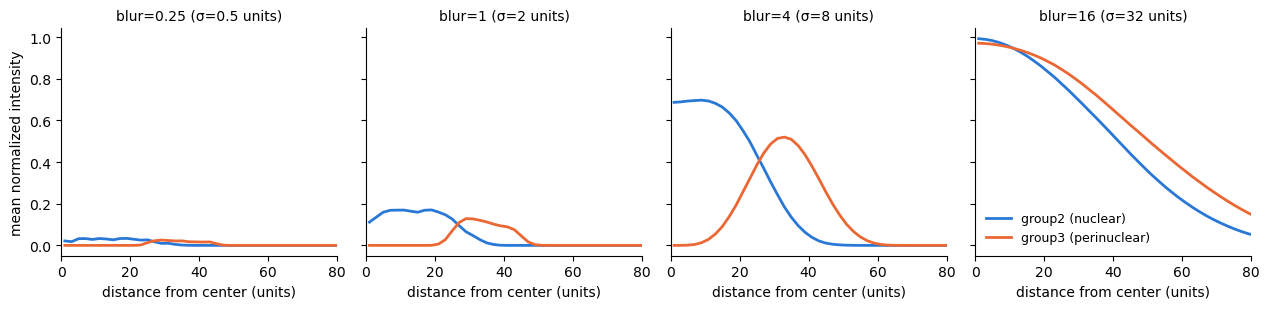

In [10]:
def radial_profile(X, Y, raster, center, bin_width):
    """Average raster intensity in rings of equal width around the center."""
    xx, yy = np.meshgrid(X, Y)
    radius = np.hypot(xx - center[0], yy - center[1])
    bins = (radius / bin_width).astype(int)
    totals = np.bincount(bins.ravel(), weights=raster.ravel())
    counts = np.bincount(bins.ravel())
    return (np.arange(len(totals)) + 0.5) * bin_width, totals / np.maximum(counts, 1)


def group_mean_raster(data, bbox, group_id, gene_id, dx, blur):
    rasters = []
    for cell_id in data.loc[data["group_id"] == group_id, "cell_id"].unique():
        x, y = cell_xy(data, cell_id, gene_id)
        X, Y, r = rasterize(bbox, x, y, dx, blur)
        rasters.append(r)
    return X, Y, np.mean(rasters, axis=0)


profile_blurs = [0.25, 1, 4, 16]
fig, axes = plt.subplots(1, len(profile_blurs), figsize=(3.2 * len(profile_blurs), 3.2), sharey=True)
for ax, blur in zip(axes, profile_blurs):
    for group_id in ["group2", "group3"]:
        X, Y, mean_r = group_mean_raster(dataset, bounding_box, group_id, "gene2", dx=1, blur=blur)
        radius, profile = radial_profile(X, Y, mean_r, (center_x, center_y), bin_width=2)
        ax.plot(radius, profile, color=GROUP_COLORS[group_id], lw=2,
                label="group2 (nuclear)" if group_id == "group2" else "group3 (perinuclear)")
    ax.set_title(f"blur={blur} (σ={2*blur:g} units)", fontsize=10)
    ax.set_xlabel("distance from center (units)")
    ax.set_xlim(0, 80)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("mean normalized intensity")
axes[-1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

##### Interpretation

At `blur = 1` and `blur = 4`, the nuclear profile is high from the center out to ~20–25 units, whereas the perinuclear profile is near zero at the center and peaks at ~30–35 units. At `blur = 16` (σ = 32 units) the hole in the ring fills in: both profiles peak at the center and overlap almost completely. At `blur = 0.25` the curves are low and flat because each image is a set of single-pixel dots (each image's single brightest pixel is 1, and most pixels are 0). The localization difference is still present in the data, but the image no longer shows it. **Choose a physical σ smaller than the smallest spatial structure you need to resolve.**

## 5. Sparse Genes, Noise, and Per-Image Normalization

Real imSRT data contain many cell–gene pairs with only one or a few transcripts, from lowly expressed genes, mis-assigned transcripts, or off-target detections. The noisy simulation mimics this with 1–3 extra transcripts of non-marker genes in each cell.

Because each image is **min–max normalized independently**, an image of 2 transcripts reaches the same maximum brightness (1.0) as an image of 50 transcripts. Blur then decides how *large* those few bright spots look. With large blur, a couple of noise transcripts become a big, bright blob that a pretrained CNN can mistake for real structure.

Noisy group2 cell 22 transcript counts:
gene_id
gene1     3
gene2    50
gene3     3


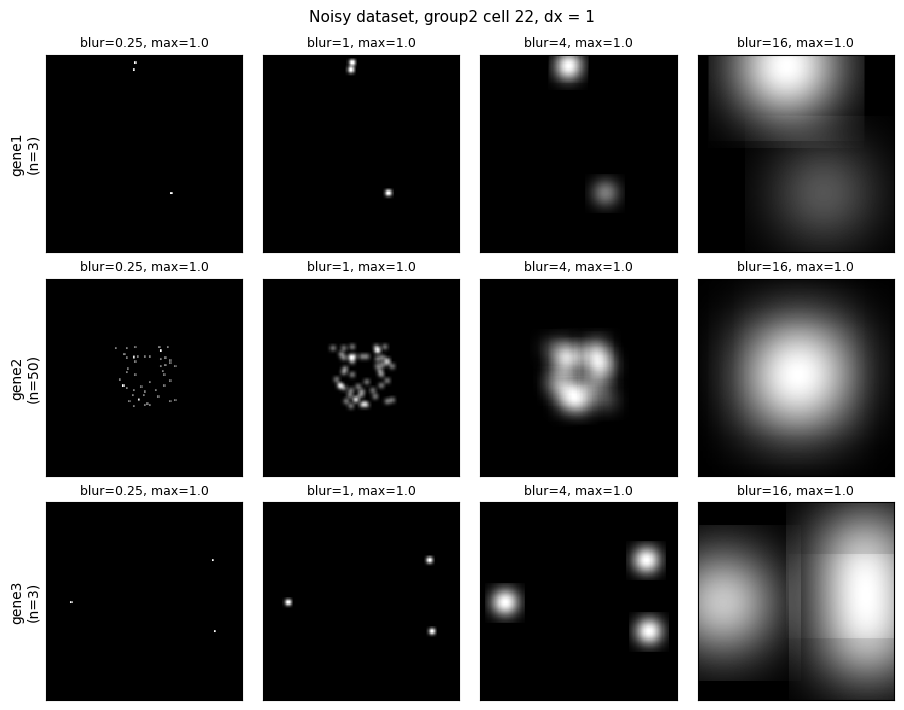

In [11]:
# Pick a group2 cell in the noisy dataset that has sparse gene1 and gene3 transcripts.
noise_counts = dataset_noise.groupby(["cell_id", "gene_id"]).size().unstack(fill_value=0)
group2_cells = dataset_noise.loc[dataset_noise["group_id"] == "group2", "cell_id"].unique()
noisy_cell = next(c for c in group2_cells if noise_counts.loc[c, "gene1"] > 0 and noise_counts.loc[c, "gene3"] > 0)
print(f"Noisy group2 cell {noisy_cell} transcript counts:")
print(noise_counts.loc[noisy_cell].to_string())

noise_blurs = [0.25, 1, 4, 16]
genes = ["gene1", "gene2", "gene3"]
fig, axes = plt.subplots(len(genes), len(noise_blurs), figsize=(2.3 * len(noise_blurs), 2.4 * len(genes)))
for row, gene_id in enumerate(genes):
    x, y = cell_xy(dataset_noise, noisy_cell, gene_id)
    for col, blur in enumerate(noise_blurs):
        X, Y, r = rasterize(bounding_box_noise, x, y, dx=1, blur=blur)
        show_raster(axes[row, col], X, Y, r, f"blur={blur}, max={r.max():.1f}")
    axes[row, 0].set_ylabel(f"{gene_id}\n(n={len(x)})", fontsize=10)
fig.suptitle(f"Noisy dataset, group2 cell {noisy_cell}, dx = 1", fontsize=11)
plt.tight_layout()
plt.show()

##### Interpretation

The `gene2` row shows the real nuclear pattern. The `gene1` and `gene3` rows each contain only a few noise transcripts, but every image has a maximum of 1.0. At small blur those transcripts are tiny dots that cover little of the image. At `blur = 16` each one becomes a large blob that dominates its image. These blobs also have hard rectangular edges. The kernel is cut off at its ±2σ window and clipped at the bounding box, and with only a few transcripts nothing smooths over those edges. Such sharp artificial edges are exactly the kind of feature a pretrained CNN responds to. When gene images are concatenated into one feature vector per cell, these noise-driven blobs add variation that is unrelated to cell identity. Section 7 measures the consequence.

Two practical consequences:

- Per-image normalization removes absolute abundance. Use the expression-weighted features shown in the other tutorials to put abundance back.
- With sparse or noisy genes, prefer smaller blur, or filter very low-count cell–gene pairs before rasterizing.

## 6. Runtime and Image Resolution

### Rasterization Time

Rasterization loops over transcripts, and each transcript writes into a window whose size depends only on `blur`. Making `dx` smaller enlarges the image array (memory grows with 1/`dx`²) but barely changes the per-transcript cost. Making `blur` larger enlarges every window (cost grows roughly with `blur`²). We time one 50-transcript cell, including figure creation.

In [12]:
x, y = cell_xy(dataset, example_cells["group2"], "gene2")

def time_raster(dx, blur, repeats=3):
    start = time.perf_counter()
    for _ in range(repeats):
        rasterize(bounding_box, x, y, dx, blur)
    return (time.perf_counter() - start) / repeats * 1000

timing = pd.DataFrame(
    [{"vary": "dx (blur=1)", "dx": dx, "blur": 1, "ms per cell": time_raster(dx, 1)} for dx in [0.25, 0.5, 1, 2, 4]]
    + [{"vary": "blur (dx=1)", "dx": 1, "blur": b, "ms per cell": time_raster(1, b)} for b in [0.25, 1, 4, 16, 32]]
)
timing.round({"ms per cell": 1})

,vary,dx,blur,ms per cell
0,dx (blur=1),0.25,1.00,37.9
1,dx (blur=1),0.50,1.00,21.0
2,dx (blur=1),1.00,1.00,17.4
3,dx (blur=1),2.00,1.00,13.5
4,dx (blur=1),4.00,1.00,13.3
5,blur (dx=1),1.00,0.25,16.9
6,blur (dx=1),1.00,1.00,17.1
7,blur (dx=1),1.00,4.00,17.2
8,blur (dx=1),1.00,16.00,21.6
9,blur (dx=1),1.00,32.00,22.7


Exact times depend on your machine. For a 50-transcript cell, most of the time goes into creating the Matplotlib figure, so neither parameter matters much. In our run, `dx = 0.25` roughly doubled the time relative to `dx = 1`, while increasing `blur` from 1 to 32 added only about 30%. The kernel window grows with `blur`², so blur cost becomes more noticeable for cells with thousands of transcripts. Multiply by the number of cell–gene images to estimate the time for a whole dataset.

### The Saved Image Has a Fixed Size

`save_image()` writes the figure that `starit()` creates, and that figure has a fixed size in pixels. The PNG therefore has the **same pixel size for every `dx`**: a coarse grid is upsampled and a fine grid is downsampled. The ResNet-101 pipeline then resizes every image to 224 × 224.

In [13]:
x, y = cell_xy(dataset, example_cells["group2"], "gene2")
for dx in [0.25, 0.5, 1, 2, 4, 8]:
    X, Y, r = rasterize(bounding_box, x, y, dx=dx, blur=1)
    png = render_png(bounding_box, x, y, dx=dx, blur=1)
    print(f"dx={dx:<5} raster grid {r.shape[1]:>4} x {r.shape[0]:<4} -> saved PNG {png.size[0]} x {png.size[1]} -> ResNet input 224 x 224")

dx=0.25  raster grid  652 x 652  -> saved PNG 369 x 369 -> ResNet input 224 x 224
dx=0.5   raster grid  326 x 326  -> saved PNG 369 x 369 -> ResNet input 224 x 224
dx=1     raster grid  163 x 163  -> saved PNG 369 x 369 -> ResNet input 224 x 224
dx=2     raster grid   82 x 82   -> saved PNG 369 x 369 -> ResNet input 224 x 224
dx=4     raster grid   41 x 41   -> saved PNG 369 x 369 -> ResNet input 224 x 224
dx=8     raster grid   21 x 21   -> saved PNG 369 x 369 -> ResNet input 224 x 224


##### Interpretation

Shrinking `dx` until the grid is much finer than the saved PNG, or than the 224 × 224 network input, costs memory without adding detail that the downstream model can see. A practical rule: **choose `dx` so the bounding box spans roughly 150–400 pixels.** Here that means `dx` ≈ 0.5–1. Going coarser than that causes visible pixelation (Section 4) and, as shown next, can hurt clustering.

## 7. Downstream Effect on Clustering

To measure the effect of `dx` and `blur` on analysis results, we repeat the unweighted pipeline from the other tutorials for several parameter settings on **both** datasets:

STARIT images (in memory) → ResNet-101 embedding per gene image → concatenate 3 genes per cell → PCA (5 components) → cosine kNN graph (k = 18) → Louvain clustering.

For each setting we report two scores:

- **ARI** (adjusted Rand index) between Louvain clusters and the four simulated groups (1 = perfect recovery).
- **Silhouette (group 2 vs 3)**: the silhouette score of the PCA embedding using the true labels of the nuclear and perinuclear groups only. It measures how far apart the two localization-only groups are, independently of Louvain. Higher is better and values near 0 mean the groups overlap.

The settings vary `blur` at `dx = 1`, vary `dx` at `blur = 1`, and compare settings with the **same physical σ = 16 units** but different `dx`.

> **Runtime:** each setting rasterizes and embeds 240 images. On a laptop CPU this takes roughly 40 s per setting per dataset (about 15 minutes in total). Remove entries from `settings` to make it faster.

In [14]:
# Match the ImageNet preprocessing used to train ResNet101.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Remove the classifier so the network returns a 2,048-value image embedding.
resnet101 = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
resnet101.fc = torch.nn.Identity()
resnet101.eval()

BLACK_PLACEHOLDER = Image.new("RGB", (369, 369))


def cell_features(data, bbox, dx, blur, batch_size=60):
    """Return a (cells x 6,144) unweighted STARIT feature matrix and the cell group labels."""
    gene_ids = sorted(data["gene_id"].unique())
    cells = data.drop_duplicates("cell_id").sort_values("cell_id")[["cell_id", "group_id"]].values
    by_cell_gene = data.groupby(["cell_id", "gene_id"])

    images = []
    for cell_id, _ in cells:
        for gene_id in gene_ids:
            if (cell_id, gene_id) in by_cell_gene.groups:
                subset = by_cell_gene.get_group((cell_id, gene_id))
                images.append(render_png(bbox, subset["x_position"], subset["y_position"], dx, blur))
            else:
                images.append(BLACK_PLACEHOLDER)  # same placeholder idea as the other tutorials

    features = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            batch = torch.stack([transform(img) for img in images[start:start + batch_size]])
            features.append(resnet101(batch).numpy())
    features = np.concatenate(features).reshape(len(cells), -1)
    return features, cells[:, 1]


def evaluate(features, labels):
    """PCA -> kNN -> Louvain, then ARI and the group2-vs-group3 silhouette."""
    pcs = PCA(n_components=5, random_state=RANDOM_SEED).fit_transform(features)
    graph = nx.from_scipy_sparse_array(
        kneighbors_graph(pcs, n_neighbors=18, metric="cosine", mode="connectivity", include_self=True)
    )
    clusters = np.array(list(cl.best_partition(graph, random_state=RANDOM_SEED).values()))
    localization_groups = np.isin(labels, ["group2", "group3"])
    return {
        "ARI": adjusted_rand_score(labels, clusters),
        "n clusters": len(set(clusters)),
        "silhouette (group2 vs 3)": silhouette_score(pcs[localization_groups], labels[localization_groups]),
    }

In [15]:
settings = [
    # vary blur at dx = 1
    (1, 0.25), (1, 1), (1, 4), (1, 8), (1, 16),
    # vary dx at blur = 1
    (0.5, 1), (2, 1), (4, 1), (8, 1),
    # same physical sigma = 16 units as (1, 8) and (8, 1)
    (2, 4), (4, 2),
]
datasets = {
    "noise-free": (dataset, bounding_box),
    "with noise": (dataset_noise, bounding_box_noise),
}

results = []
for dataset_name, (data, bbox) in datasets.items():
    for dx, blur in settings:
        start = time.perf_counter()
        features, labels = cell_features(data, bbox, dx, blur)
        scores = evaluate(features, labels)
        results.append({"dataset": dataset_name, "dx": dx, "blur": blur, "sigma (units)": 2 * dx * blur, **scores})
        print(f"{dataset_name:<10} dx={dx:<4} blur={blur:<5} ARI={scores['ARI']:.3f} "
              f"silhouette(2 vs 3)={scores['silhouette (group2 vs 3)']:.3f}  ({time.perf_counter() - start:.0f} s)")

results = pd.DataFrame(results)

noise-free dx=1    blur=0.25  ARI=1.000 silhouette(2 vs 3)=0.592  (37 s)
noise-free dx=1    blur=1     ARI=1.000 silhouette(2 vs 3)=0.611  (39 s)
noise-free dx=1    blur=4     ARI=1.000 silhouette(2 vs 3)=0.629  (39 s)
noise-free dx=1    blur=8     ARI=1.000 silhouette(2 vs 3)=0.861  (39 s)
noise-free dx=1    blur=16    ARI=1.000 silhouette(2 vs 3)=0.830  (40 s)
noise-free dx=0.5  blur=1     ARI=1.000 silhouette(2 vs 3)=0.648  (39 s)
noise-free dx=2    blur=1     ARI=0.934 silhouette(2 vs 3)=0.344  (38 s)
noise-free dx=4    blur=1     ARI=1.000 silhouette(2 vs 3)=0.626  (38 s)
noise-free dx=8    blur=1     ARI=1.000 silhouette(2 vs 3)=0.778  (38 s)
noise-free dx=2    blur=4     ARI=1.000 silhouette(2 vs 3)=0.753  (39 s)
noise-free dx=4    blur=2     ARI=1.000 silhouette(2 vs 3)=0.719  (38 s)
with noise dx=1    blur=0.25  ARI=0.934 silhouette(2 vs 3)=0.449  (41 s)
with noise dx=1    blur=1     ARI=1.000 silhouette(2 vs 3)=0.408  (41 s)
with noise dx=1    blur=4     ARI=0.966 silhouette(

In [16]:
results.round(3)

,dataset,dx,blur,sigma (units),ARI,n clusters,silhouette (group2 vs 3)
0,noise-free,1.0,0.25,0.5,1.000,4,0.592
1,noise-free,1.0,1.00,2.0,1.000,4,0.611
2,noise-free,1.0,4.00,8.0,1.000,4,0.629
3,noise-free,1.0,8.00,16.0,1.000,4,0.861
4,noise-free,1.0,16.00,32.0,1.000,4,0.830
5,noise-free,0.5,1.00,1.0,1.000,4,0.648
6,noise-free,2.0,1.00,4.0,0.934,4,0.344
7,noise-free,4.0,1.00,8.0,1.000,4,0.626
8,noise-free,8.0,1.00,16.0,1.000,4,0.778
9,noise-free,2.0,4.00,16.0,1.000,4,0.753


### Visualize the Sweep

The left panel varies `blur` at `dx = 1`. The middle panel varies `dx` at `blur = 1`. The right panel holds the physical σ fixed at 16 units and varies only `dx`. A horizontal line at 0 marks complete overlap of groups 2 and 3.

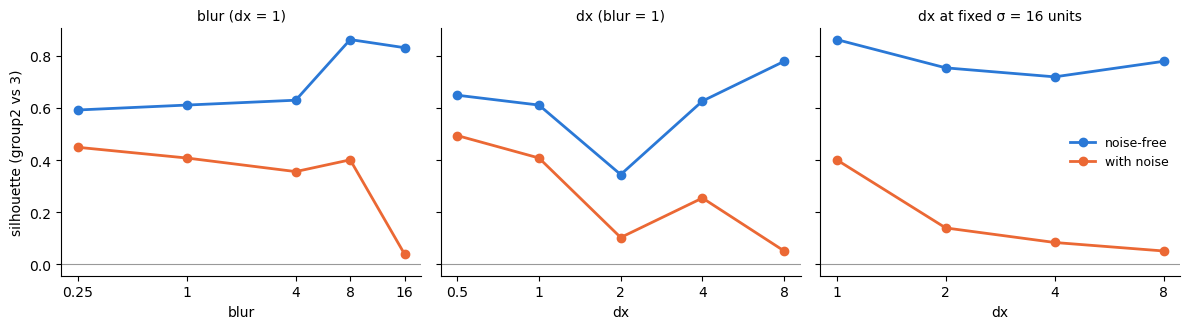

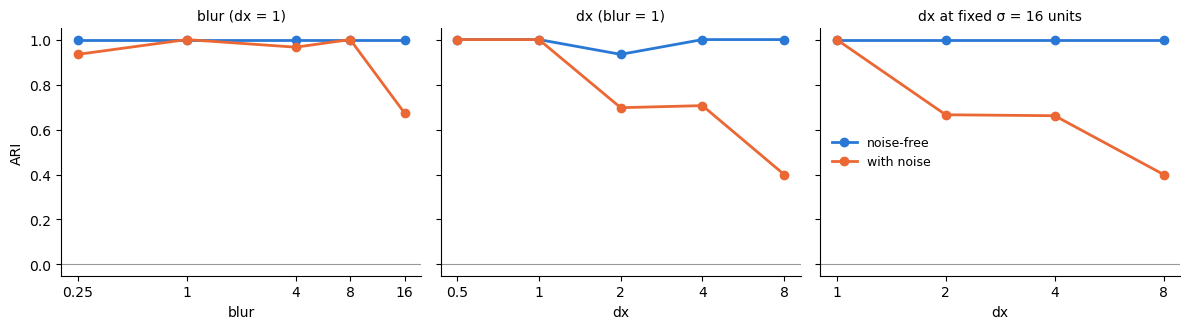

In [17]:
panels = [
    ("blur (dx = 1)", results[(results["dx"] == 1)], "blur", True),
    ("dx (blur = 1)", results[(results["blur"] == 1)], "dx", True),
    ("dx at fixed σ = 16 units", results[results["sigma (units)"] == 16], "dx", True),
]

for metric in ["silhouette (group2 vs 3)", "ARI"]:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
    for ax, (title, subset, x_col, log_x) in zip(axes, panels):
        for dataset_name, color in DATASET_COLORS.items():
            s = subset[subset["dataset"] == dataset_name].sort_values(x_col)
            ax.plot(s[x_col], s[metric], "-o", color=color, lw=2, ms=6, label=dataset_name)
        ax.axhline(0, color="#999999", lw=0.8)
        if log_x:
            ax.set_xscale("log", base=2)
            ax.set_xticks(sorted(subset[x_col].unique()))
            ax.set_xticklabels([f"{v:g}" for v in sorted(subset[x_col].unique())])
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(x_col)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel(metric)
    axes[-1].legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

##### Interpretation

Read the numbers from your own run in the table above. In our run:

- **Noise-free data are robust.** With 50 clean transcripts per marker gene, every setting recovers the four groups (ARI 0.93–1.0). Larger blur (`blur = 8–16` at `dx = 1`) even increases the group 2 vs 3 silhouette (≈ 0.83–0.86 vs ≈ 0.6), because the scattered dots become smooth disk and ring shapes.
- **Noise makes the choice matter.** On the noisy data, `dx ≤ 1` with `blur` between 0.25 and 8 recovers the groups well (ARI 0.93–1.0). At `blur = 16` (σ = 32 units) the nuclear and perinuclear groups collapse together (silhouette ≈ 0.04, ARI ≈ 0.67). This is the merging seen in Section 4, plus the enlarged noise blobs from Section 5.
- **Pixel size matters beyond σ.** On the noisy data, every setting with `dx ≥ 2` performs poorly (ARI 0.40–0.71, silhouette ≤ 0.26), **including** settings with the same physical σ = 16 units as the well-performing `dx = 1, blur = 8`. A coarse grid (82 × 82 pixels or fewer here) loses spatial detail that a finer grid at the same σ keeps.
- **Individual scores are noisy.** For example, the noise-free silhouette dips at `dx = 2` and recovers at `dx = 4`. With 80 cells and a pretrained CNN, single settings can fluctuate, so look for stable regions rather than the single best score.

The best values are dataset-specific. Your cell size, transcript density, noise level, and the scale of the localization differences you care about all change the optimum. Section 8 turns these observations into a checklist.

## 8. Choosing `dx` and `blur` for Your imSRT Data

Use this checklist as a starting point, then check your choice visually (Sections 4–5) and, if you have known cell types or states, quantitatively (Section 7).

**1. Know your coordinate units.** `dx` is in the units of your *x,y* coordinates. Many platforms report transcript positions in micrometers, but some report camera pixels or millimeters. A `dx` of 1 means 1 µm in one dataset and 1 pixel (≈ 0.1–0.2 µm) in another. Check your platform's documentation, and convert all datasets to the same unit before comparing them.

**2. Pick `dx` from the size of the bounding box.** Aim for roughly 150–400 pixels across the bounding box (`dx ≈ box width / 150–400`).
- Much finer grids add memory but no detail the saved PNG and the 224 × 224 CNN input can keep.
- Much coarser grids pixelate subcellular structure.
- If you build a bounding box per cell (or per cell centered at its centroid) rather than one per dataset, use the typical cell diameter in place of the box width.

**3. Pick `blur` from the physical smoothing you want: σ = 2 · `blur` · `dx`.**
- **Upper limit:** σ should be smaller than the smallest structure that distinguishes your cell states, such as the nuclear radius, the distance between nucleus and membrane, or the size of a protrusion. In the simulation the nuclear–perinuclear gap is ~10–15 units, and σ = 32 erased it.
- **Lower limit:** σ should be large enough that transcripts of a typical gene form a density rather than isolated dots. Sparse genes need more smoothing to look continuous, but also turn noise into larger blobs.
- A good first try is σ around the typical distance between neighboring transcripts of a moderately expressed gene, and well below the compartment size.

**4. If you change `dx`, rescale `blur`.** Keep `blur × dx` constant to keep the same physical smoothing.

**5. Use the same `dx`, `blur`, and bounding box for every cell, gene, and sample you plan to compare.** STARIT images are only comparable when they are made with identical parameters in the same coordinate frame.

**6. Watch out for sparse and noisy genes.** Per-image min–max normalization makes a single transcript as bright as a dense pattern. Prefer smaller blur when many cell–gene pairs have only a few transcripts, consider filtering very low-count pairs, and use expression-weighted features (see the other tutorials) to restore abundance information.

**7. Beware of large blur artifacts.** Each transcript's kernel is cut off at ±2σ and clipped at the bounding-box edge, then renormalized. With very large blur this creates hard-edged rectangular blobs, especially for sparse genes (Section 5), and piles intensity up at the frame edge for transcripts near it. Keep σ well below the size of the bounding box. If σ is larger than the margin added by `get_bounding_box(..., expand=1.1)`, increase `expand`.

**8. Budget compute.** Memory per image grows with 1/`dx`², and the kernel window per transcript grows with `blur`². Time a few cells (Section 6) before rasterizing a whole dataset.

**9. When in doubt, sweep.** If you have known labels (cell types, marker-defined states, or a simulation like this one), run a small grid of `dx` and `blur` values as in Section 7 and choose the region where results are stable, rather than the single best score.

### Advanced: Multi-Scale Blur

`blur` can also be a list (for example `blur=[4, 2, 1]`), which produces one channel per scale. With `wavelet_magnitude=True` (and `blur` sorted from largest to smallest), each channel holds the difference between neighboring scales, which highlights structure at a particular size. Note that with `wavelet_magnitude=True`, the first listed scale is kept as is and the remaining channels are differences. The saved figure shows up to three scales as RGB channels. This is useful for exploring which spatial scale carries signal in your data. The analyses in this and the other tutorials use a single blur value.

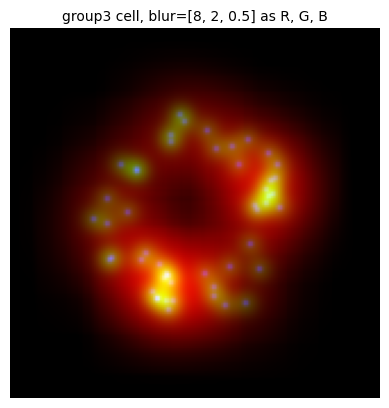

In [18]:
x, y = cell_xy(dataset, example_cells["group3"], "gene2")
with contextlib.redirect_stdout(io.StringIO()):
    _, _, fig_multi = starit(bounding_box, x, y, dx=1, blur=[8, 2, 0.5], draw=10000)
fig_multi.axes[0].set_title("group3 cell, blur=[8, 2, 0.5] as R, G, B", fontsize=10)
plt.show()

## Summary

- `dx` sets the pixel size in coordinate units. `blur` sets the Gaussian width **in pixels**, so the physical smoothing is σ = 2 · `blur` · `dx`.
- Too little smoothing gives isolated dots. Too much merges nearby compartments (here, nuclear vs perinuclear) and enlarges sparse noise transcripts.
- The saved image has a fixed pixel size, so very small `dx` adds cost but not detail. Very large `dx` pixelates the cell and hurts clustering even at a fixed σ.
- Clean, dense data tolerate a wide range of settings. Sparse, noisy data, which is typical of real imSRT, are much more sensitive. Check visually and, where possible, with a small parameter sweep.